In [6]:
import pandas as pd
print("Working ✅")

df = pd.read_excel("Online Retail (1).xlsx")
df.head()

Working ✅


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df = df.dropna(subset=['Description'])

In [13]:
# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Extract features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [14]:
df.shape
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8


<Axes: title={'center': 'Monthly Sales'}, xlabel='Month'>

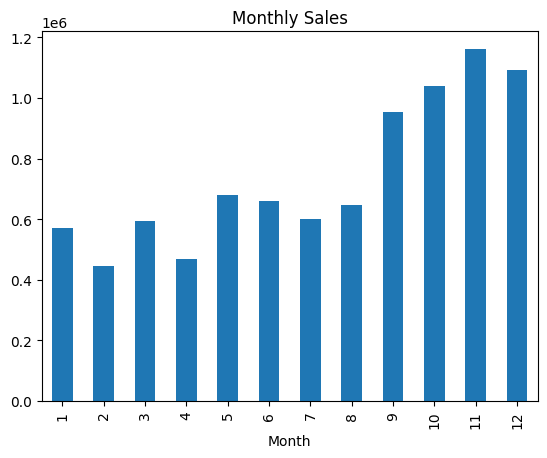

In [15]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='bar', title='Monthly Sales')

<Axes: title={'center': 'Top Countries by Sales'}, xlabel='Country'>

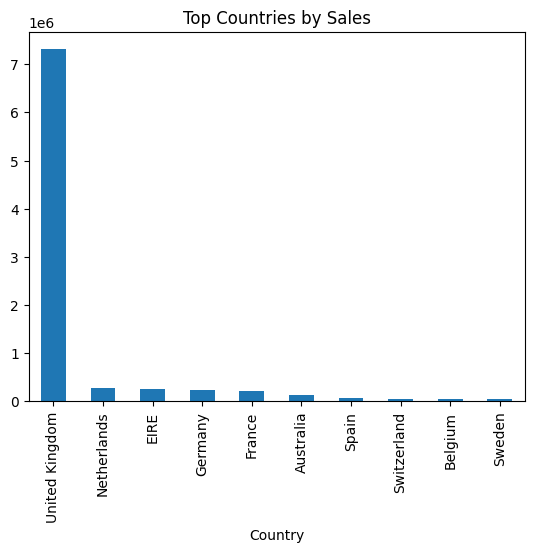

In [16]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', title='Top Countries by Sales')

<Axes: title={'center': 'Sales by Hour'}, xlabel='Hour'>

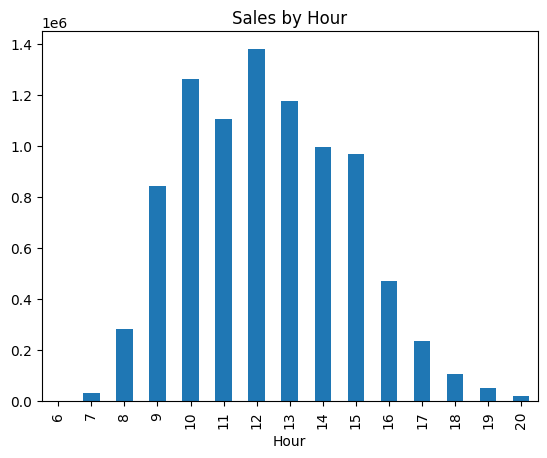

In [17]:
hourly_sales = df.groupby('Hour')['TotalPrice'].sum()

hourly_sales.plot(kind='bar', title='Sales by Hour')

<Axes: title={'center': 'Top Selling Products'}, xlabel='Description'>

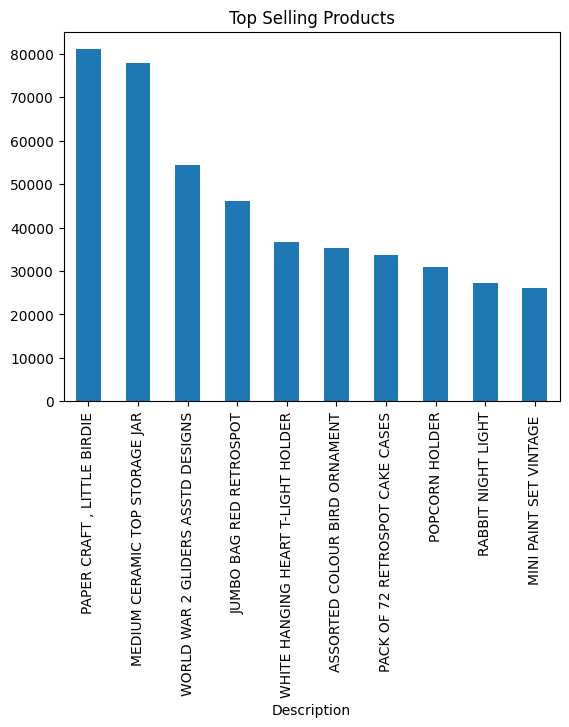

In [18]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', title='Top Selling Products')

MAE: 12.05573836423217
MSE: 2809.606868544104
RF MAE: 0.20914173944742637
RF MSE: 105.48935553342663


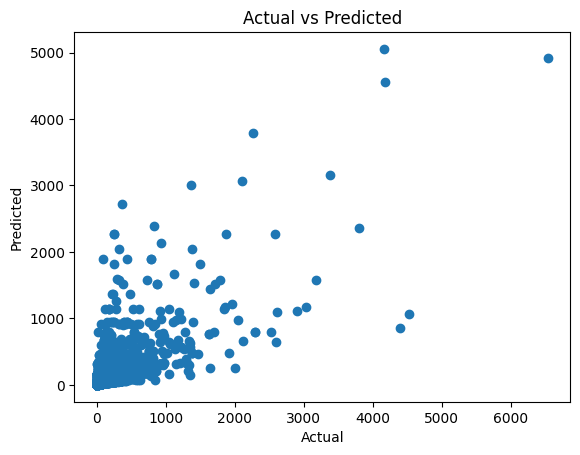

In [25]:
# Selecting Features
X = df[['Quantity', 'UnitPrice', 'Month', 'Day', 'Hour']]
y = df['TotalPrice']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training First Model (Linear Regression)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluating Model
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Comparing Models
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF MSE:", mean_squared_error(y_test, y_pred_rf))

#Visualization
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()